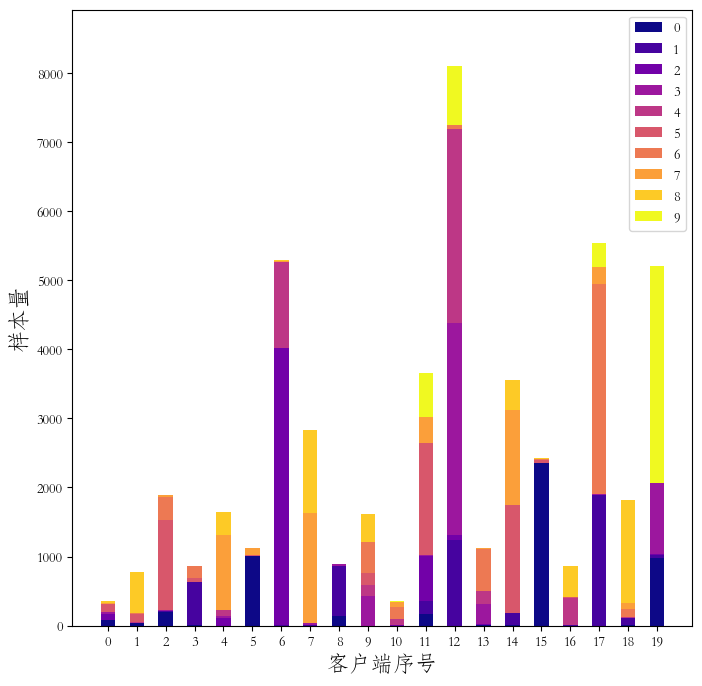

In [38]:
import ujson
import os
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体为宋体
plt.rcParams['font.family'] = 'STFangsong'

# 读取客户端
path = os.path.join("dataset/rawdata/", "cifar10", "dirichlet", "config.json")
with open(path, "r") as f:
    config = ujson.load(f)
    data = config["statistic"]

# 数据
labels = data
tags = list(range(0, 10))

# 为每个标签的柱状图生成一个颜色
colors = plt.cm.plasma(np.linspace(0, 1, len(tags)))

# 柱在图横轴的位置
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(8, 8))

# 用于记录每个用户的累计高度
cumulative_heights = np.zeros(len(labels))

for i, tag in enumerate(tags):
    # 遍历标签，为每个标签生成一个柱状图
    sample_counts = [user_data[str(tag)] if str(tag) in user_data else 0 for user_data in data]
    ax.bar(x, sample_counts, width=0.5, label=str(tag), color=colors[i], bottom=cumulative_heights)
    cumulative_heights += np.array(sample_counts)


ax.set_ylabel('样本量', fontsize=16)
ax.set_ylim(0, max(cumulative_heights) * 1.1)

ax.set_xlabel('客户端序号', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(np.arange(0, len(labels)))

# ax.set_title('每个用户的样本量', fontsize=20)
ax.legend(loc="best", bbox_to_anchor=(1, 1))

plt.show()


In [39]:
import copy
from torch import nn
from src.models import Net, BaseHeadMerge

dim = 16 * 5 * 5  # cifar10 图片尺寸为 3*32*32，彩色
model = Net(in_channels=3, num_classes=10, dim=dim)

head = copy.deepcopy(model.fc)
fc = nn.Identity()
model = BaseHeadMerge(base=model, head=head)

base_params = sum(p.numel() for p in model.base.parameters() if p.requires_grad)
head_params = sum(p.numel() for p in model.head.parameters() if p.requires_grad)
print(f"base_params: {base_params}, head_params: {head_params}")
print(f"total_params: {base_params + head_params}")

base_params: 62006, head_params: 850
total_params: 62856


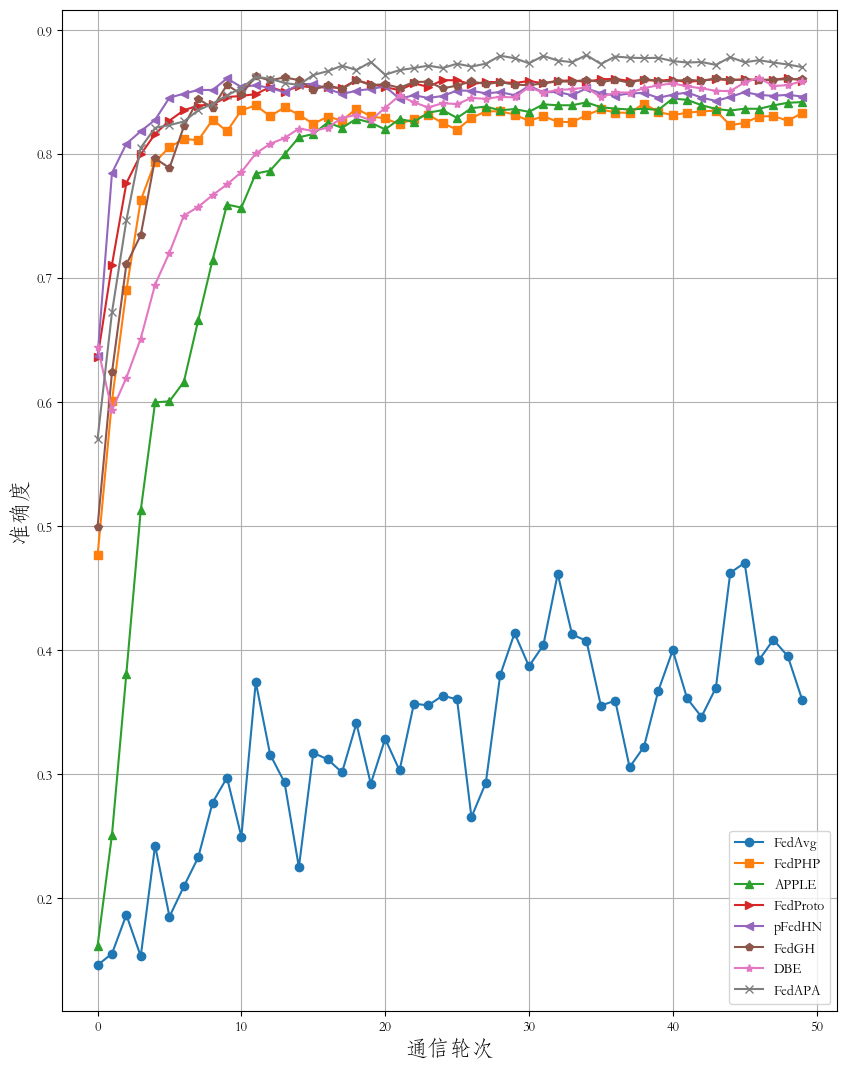

In [5]:
""" FedAPA 用图 """
import os
import ujson
import matplotlib.pyplot as plt

# 设置中文字体为宋体
plt.rcParams['font.family'] = 'STFangsong'


num_clients = 20
algorithms = ["FedAvg", "FedPHP", "APPLE", "FedProto", "pFedHN", "FedGH", "DBE", "FedAPA"]
markers = ['o', 's', '^', '>', '<', 'p', '*', 'x', '+']

communication_rounds = list(range(0, 50))  # 生成轮次列表
plt.figure(figsize=(10, 13))

for index, algorithm in enumerate(algorithms):
    # 读取客户端
    filename = algorithm + "-" + str(num_clients) + ".json"
    path = os.path.join("results", "cifar10", "non-balanced", filename)
    with open(path, "r") as f:
        result = ujson.load(f)
        if algorithm == "FedAPA" or algorithm == "FedCPCL":
            best_index = result["best_acc"].index(max(result["best_acc"]))
        else:
            best_index = result["best_acc"].index(min(result["best_acc"]))
        acc_record = result["experiment"][best_index]["acc_record"]
        accuracy = [acc_record[str(round)] for round in communication_rounds]
        plt.plot(communication_rounds, accuracy, label=algorithm, marker=markers[index])

# 添加图例、标题和坐标轴标签
plt.legend()
# plt.title('CIFAR-10数据集病态数据分布场景中各算法的Top-1准确度随通信轮次的变化(20个用户)')
plt.xlabel('通信轮次', fontsize=16)
plt.ylabel('准确度', fontsize=16)
plt.grid(True)
plt.show()


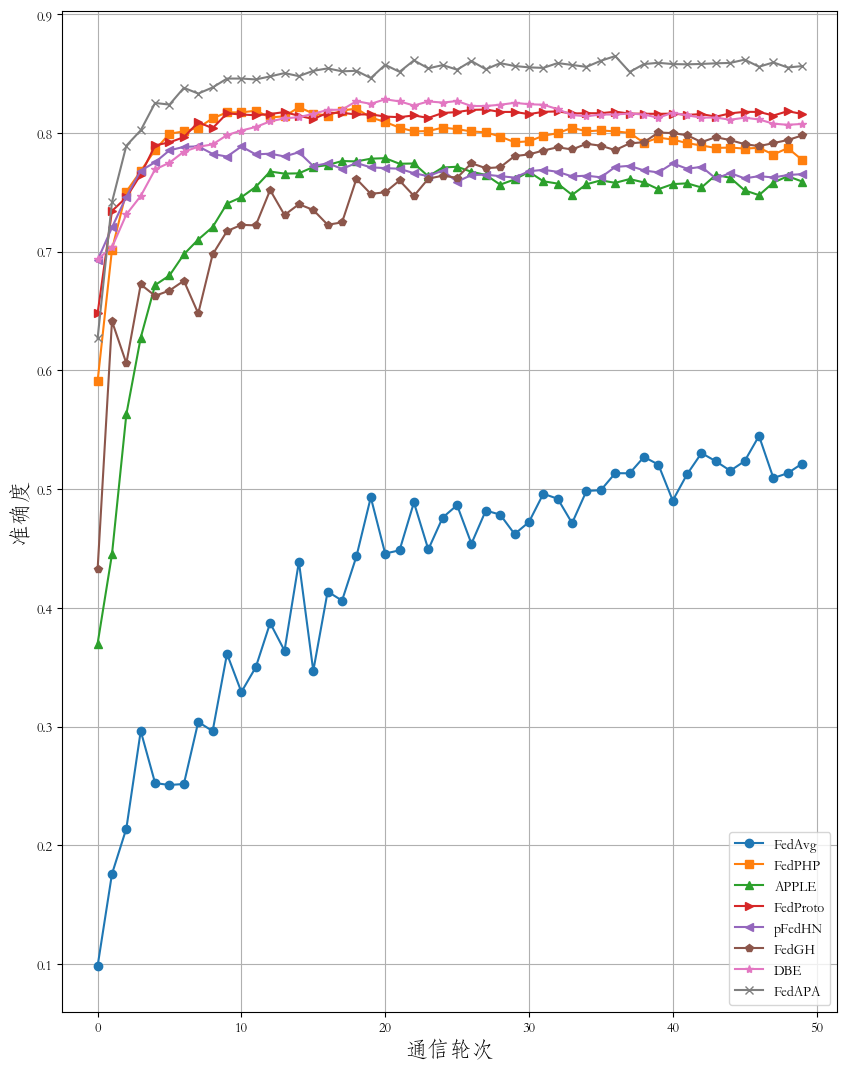

In [6]:
""" FedAPA 用图 """
import os
import ujson
import matplotlib.pyplot as plt

# 设置中文字体为宋体
plt.rcParams['font.family'] = 'STFangsong'


num_clients = 20
algorithms = ["FedAvg", "FedPHP", "APPLE", "FedProto", "pFedHN", "FedGH", "DBE", "FedAPA"]
markers = ['o', 's', '^', '>', '<', 'p', '*', 'x', '+']

communication_rounds = list(range(0, 50))  # 生成轮次列表
plt.figure(figsize=(10, 13))

for index, algorithm in enumerate(algorithms):
    # 读取客户端
    filename = algorithm + "-" + str(num_clients) + ".json"
    path = os.path.join("results", "cifar10", "dirichlet", filename)
    with open(path, "r") as f:
        result = ujson.load(f)
        if algorithm == "FedAPA" or algorithm == "FedCPCL":
            best_index = result["best_acc"].index(max(result["best_acc"]))
        else:
            best_index = result["best_acc"].index(min(result["best_acc"]))
        acc_record = result["experiment"][best_index]["acc_record"]
        accuracy = [acc_record[str(round)] for round in communication_rounds]
        plt.plot(communication_rounds, accuracy, label=algorithm, marker=markers[index])

# 添加图例、标题和坐标轴标签
plt.legend()
# plt.title('CIFAR-10数据集实际数据分布场景中各算法的Top-1准确度随通信轮次的变化(20个用户)')
plt.xlabel('通信轮次', fontsize=16)
plt.ylabel('准确度', fontsize=16)
plt.grid(True)
plt.show()


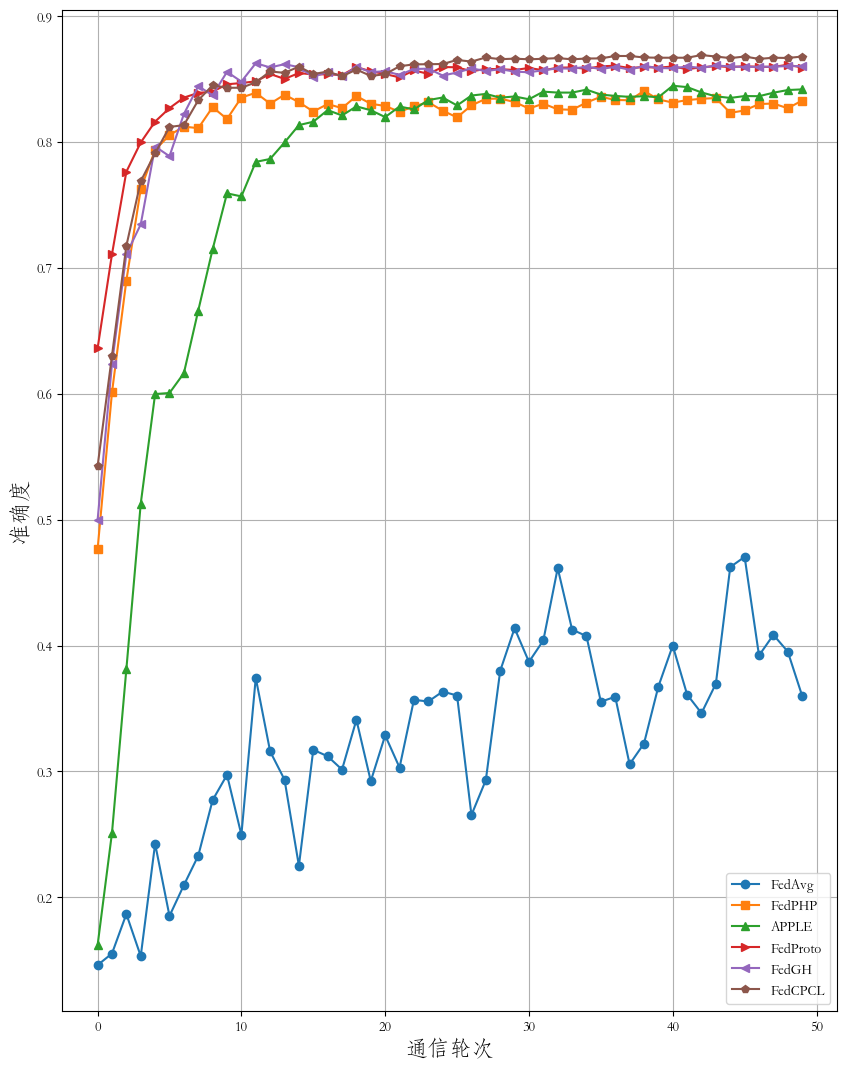

In [49]:
""" FedCPCL 用图 """

import matplotlib.pyplot as plt

# 设置中文字体为宋体
plt.rcParams['font.family'] = 'STFangsong'


num_clients = 20
algorithms = ["FedAvg", "FedPHP", "APPLE", "FedProto", "FedGH", "FedCPCL"]
markers = ['o', 's', '^', '>', '<', 'p', '*', 'x', '+']

communication_rounds = list(range(0, 50))  # 生成轮次列表
plt.figure(figsize=(10, 13))

for index, algorithm in enumerate(algorithms):
    # 读取客户端
    filename = algorithm + "-" + str(num_clients) + ".json"
    path = os.path.join("results", "cifar10", "non-balanced", filename)
    with open(path, "r") as f:
        result = ujson.load(f)
        if algorithm == "FedCPCL":
            best_index = result["best_acc"].index(max(result["best_acc"]))
        else:
            best_index = result["best_acc"].index(min(result["best_acc"]))
        acc_record = result["experiment"][best_index]["acc_record"]
        accuracy = [acc_record[str(round)] for round in communication_rounds]
        plt.plot(communication_rounds, accuracy, label=algorithm, marker=markers[index])

# 添加图例、标题和坐标轴标签
plt.legend()
# plt.title('CIFAR-10数据集病态数据分布场景中各算法的Top-1准确度随通信轮次的变化(20个用户)')
plt.xlabel('通信轮次', fontsize=16)
plt.ylabel('准确度', fontsize=16)
plt.grid(True)
plt.show()


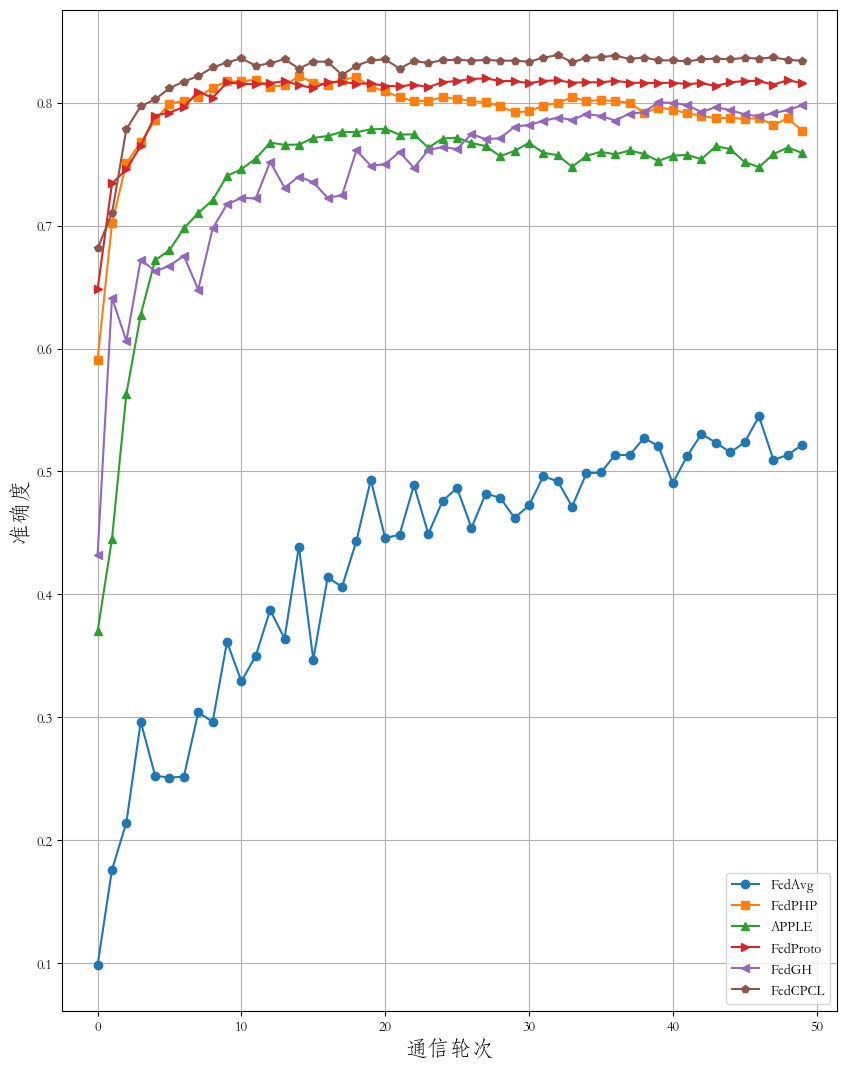

In [48]:
""" FedCPCL 用图 """

import matplotlib.pyplot as plt

# 设置中文字体为宋体
plt.rcParams['font.family'] = 'STFangsong'


num_clients = 20
algorithms = ["FedAvg", "FedPHP", "APPLE", "FedProto", "FedGH", "FedCPCL"]
markers = ['o', 's', '^', '>', '<', 'p', '*', 'x', '+']

communication_rounds = list(range(0, 50))  # 生成轮次列表
plt.figure(figsize=(10, 13))

for index, algorithm in enumerate(algorithms):
    # 读取客户端
    filename = algorithm + "-" + str(num_clients) + ".json"
    path = os.path.join("results", "cifar10", "dirichlet", filename)
    with open(path, "r") as f:
        result = ujson.load(f)
        if algorithm == "FedCPCL":
            best_index = result["best_acc"].index(max(result["best_acc"]))
        else:
            best_index = result["best_acc"].index(min(result["best_acc"]))
        acc_record = result["experiment"][best_index]["acc_record"]
        accuracy = [acc_record[str(round)] for round in communication_rounds]
        plt.plot(communication_rounds, accuracy, label=algorithm, marker=markers[index])

# 添加图例、标题和坐标轴标签
plt.legend()
# plt.title('CIFAR-10数据集实际数据分布场景中各算法的Top-1准确度随通信轮次的变化(20个用户)')
plt.xlabel('通信轮次', fontsize=16)
plt.ylabel('准确度', fontsize=16)
plt.grid(True)
plt.show()
